# ML for linear regression

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data preparation

In [2]:
df=pd.read_csv("data/data.csv")
df.columns=df.columns.str.lower().str.replace(" ","_")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
strings=list(df.dtypes[df.dtypes=="object"].index) #solo queremos objetos
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [4]:
for col in strings:
    df[col]=df[col].str.lower().str.replace(" ","_") #reemplazamos espacios por guiones bajos y pasamos a minusculas

In [5]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## EDA

In [8]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

### Distribución de variables

In [15]:
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

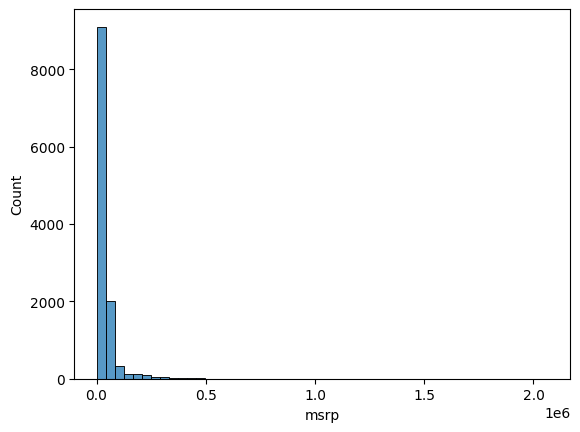

In [19]:
sns.histplot(df.msrp,bins=50)

##### Muchos autos son baratos, por ende destaca una sola barra, pero a su vez hay "outliers" que hacen que el gráfico se extienda bastante por la cola derecha. Podemos aplicar distribución logarítmica (recordemos que no podemos tener 0)

<Axes: xlabel='msrp', ylabel='Count'>

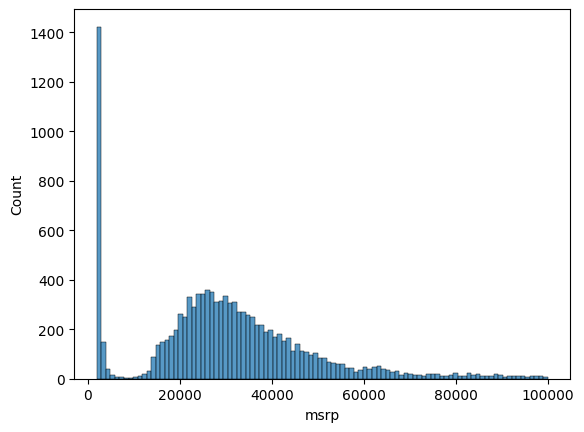

In [22]:
sns.histplot(df.msrp[df.msrp<100000],bins=100)

In [25]:
price_logs=np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

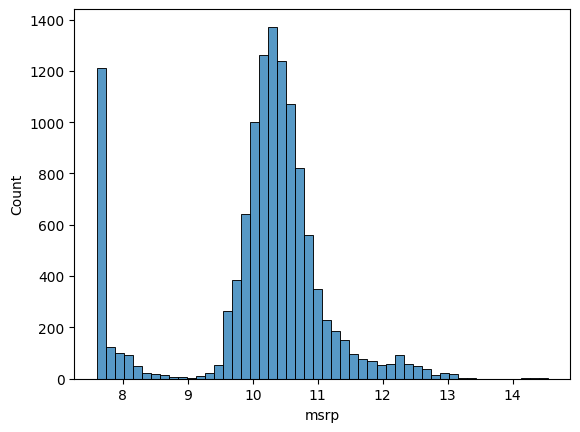

In [27]:
sns.histplot(price_logs,bins=50)

### Valores faltantes

In [29]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Entorno de validación
#### El dataset se divide entres partes: entrenamiento (60%), validación (20%) y test (20%). Para cada parte, creamos una matriz Xy.

In [76]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n,n_val+n_test+n_train 

(11914, 11914)

In [77]:
n_val,n_test,n_train

(2382, 2382, 7150)

In [78]:
df_train=df.iloc[n_train:]
df_val=df.iloc[n_train:n_train+n_val]
df_test=df.iloc[n_train+n_val:] 
#esto no  nos va a servir porque el dataframe tenía un orden predeterminado, por ejemplo, todas los autos bmw estaban juntos

In [79]:
idx=np.arange(n)

In [80]:
np.random.seed(2)
np.random.shuffle(idx)
idx #indices aleatorios

array([2735, 6720, 5878, ..., 6637, 2575, 7336])

In [81]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]] # uso idx para que los conjuntos de train, validation y test sean aleatorios

In [82]:
len(df_train),len(df_test),len(df_val)

(7150, 2382, 2382)

In [83]:
df_train=df_train.reset_index(drop=True)
df_val=df_test.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [84]:
y_train=np.log1p(df_train.msrp.values) # el .values sirve para haerlo como una matriz
y_val=np.log1p(df_val.msrp.values)
y_test=np.log1p(df_test.msrp.values)


In [85]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## Regresión lineal

$g(x_{i})\approx y_{i}$


$x_{i}=(x_{i1},x_{i2},...,x_{in})$ $\rightarrow$ son las diferentes especificaciones de los autos

$g(x_{i1},...,x_{in}) \approx y_{i}$ $\rightarrow$ esto es lo que queremos estimar



In [86]:
df_train.iloc[10] #primero entrenamos (es decir, usamos el train)

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

### Implementación

$g(x_{i})=w_{0}+w_{1}x_{i1}+w_{2}x_{i2}+... \rightarrow$ formula de la regresión lineal

$g(x_{i})=w_{0}+\Sigma_{j=0}^{n-1}w_{j}x_{ij} \rightarrow$ formula generalizada (para el caso de Python donde el conteo empieza en 0 y no en 1)

In [97]:
xi=[453,11,86]
w0=5.234
wi=[0.4,0.01,0.005]

In [98]:
def linear_regression(xi):
    n=len(xi)
    pred=w0
    for j in range(n):
        pred=pred+wi[j]*xi[j]
    return pred



In [99]:
linear_regression(xi)

186.97400000000005

In [102]:
np.log1p(186.97400000000005)

np.float64(5.236303655393576)

## Regresión lineal: forma vectorial

Recordando, 

$$g(x_{i})=w_{0}+\Sigma_{j=0}^{n-1}w_{j}x_{ij}$$ 

El segundo término no es más que un producto punto, por lo que se puede expresar 

$$g(x_{i})=w_{0}+X_{i}^Tw$$


In [126]:
def dot_product(xi,wi):
    n=len(xi)
    res=0.0
    for j in range(n):
        res=res+xi[j]*wi[j]
    return res

In [120]:
w_new=[w0]+wi
w_new

[5.234, 0.4, 0.01, 0.005]

In [121]:
def linear_regression(xi):
    xi=[1]+xi
    return dot_product(xi,w_new)

In [122]:
linear_regression(xi)

186.97400000000005

In [125]:
x1=[1,148,24,1385]
x2=[1,136,26,1244]
x3=[1,453,11,86]

x=[x1,x2,x3]
X=np.array(x)
X

array([[   1,  148,   24, 1385],
       [   1,  136,   26, 1244],
       [   1,  453,   11,   86]])

In [128]:
X.dot(w_new)

array([ 71.599,  66.114, 186.974])

## Entrenamiento de una regresión lineal: ecuación normal

Lo que buscamos es que $g(x)=Xw=Y$, pero es muy dificil que sea $Xw=Y$, por lo que tratamos de resolver ese sistema tratando de encontrar el $w$.

Suponemos que $X$ es invertible por lo que, multiplicando ambos miembros por $X^{-1}$,

$$X^{-1}Xw=X^{-1}Y$$

$$Iw=X^{-1}Y$$

Ahora bien, $X$ debe ser invertible, caso contrario no se podría solucionar este sistema.

Otra solución es como sigue: multiplicamos ambos miembros por la transpuesta de X

$$X^{T}Xw=X^{T}Y$$

y como $X^{T}X$ es una matriz cuadrada, su inversa existe, por lo que, multiplicando ambos lados,

$$(X^{T}X)^{-1}X^{T}Xw=(X^{T}X)^{-1}X^{T}Y$$

$$\boxed{w=(X^{T}X)^{-1}X^{T}Y}$$

donde $w$ es la solución posible más cercana a la ideal


In [129]:
def train_linear_regression(X,y):
    pass

In [186]:
x=[
[148,24,453],
[136,26,564],
[453,11,264],
[178,44,605],
[126,23,233],
[483,44,756],
[118,34,234],
[126,12,143],
[453,71,432],
]
X=np.array(x)
X

array([[148,  24, 453],
       [136,  26, 564],
       [453,  11, 264],
       [178,  44, 605],
       [126,  23, 233],
       [483,  44, 756],
       [118,  34, 234],
       [126,  12, 143],
       [453,  71, 432]])

In [187]:
y=[100,354,786,123,234,768,452,926,275]

In [188]:
XTX=X.T.dot(X)
XTX

array([[ 761467,   81740, 1006862],
       [  81740,   12115,  134027],
       [1006862,  134027, 1846680]])

In [189]:
XTX_inv=np.linalg.inv(XTX)

In [190]:
w_full=XTX_inv.dot(X.T).dot(y)

In [191]:
w0=w_full[0]
w=w_full[1:]

In [192]:
w0,w

(np.float64(1.6876104064487578), array([-5.87425098,  0.32875671]))

In [193]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

In [194]:
train_linear_regression(X,y)

(np.float64(557.8603593305188), array([ 1.27503107, -9.42959078, -0.3011497 ]))

## Modelo básico para estimar el precio de los autos

In [195]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [196]:
base=['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

In [197]:
X_train=df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [198]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [199]:
X_train=df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [203]:
w0,w=train_linear_regression(X_train,y_train)

In [206]:
y_pred=w0+X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015, 11.9778914 ,  9.99863111])

<Axes: ylabel='Count'>

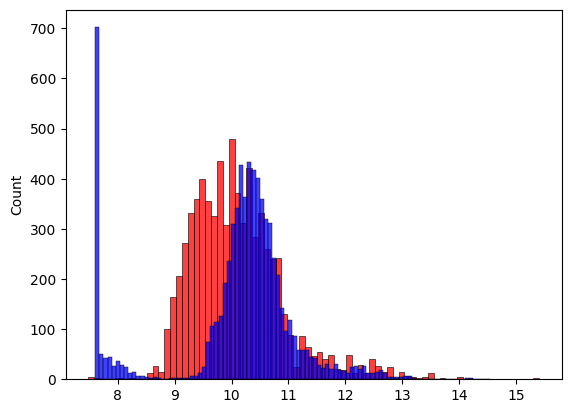

In [ ]:
sns.histplot(y_pred,color='red') #predicciones
sns.histplot(y_train,color='blue') #target